# Ti64 Statistical Modelling
## Plotting Beta approach curves from literature
### Rory Atlasi Barker, Guy Bowker

This notebook can be used to filter beta-approach curves for Ti64 volume fraction measurments from literature.
Change the temperature range, microstructure, strain rate, or other options in the example cells at the bottom to plot the corresponding curves for those conditions.
Functions can be found next to this notebook in `utils.py`.
To add data from a paper, simply create a new file in this repository named after the paper authors as shown containing the data as a `.csv` file.
Then add the papers metadata and relative filepath to the `beta-approach_curves.yaml` file.

In [1]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
from scipy.optimize import curve_fit
import yaml
from yaml.loader import FullLoader
from yaml.loader import SafeLoader
from utils import sort_curve
from utils import curve_filter
from utils import curve_filter_pd
from utils import beta_approach_curve_filter
from utils import beta_approach_curve_plotter

%matplotlib inline

Load `beta-approach_curves.yml` file and show all papers:

In [2]:
lit_data = yaml.load(open('beta-approach_curves.yml'), Loader=SafeLoader)
lit_data['Papers'].keys()

dict_keys(['Janda_2022', 'Semiatin_2002', 'Tamiri_2005', 'Villa_2019', 'Reddy_2006'])

Save paper metadata and beta-approach curves to a dictionary `lit_data`, which can be saved to a `.pkl` file to be plotted alongside other data in a different code. The `lit_data` dictionary can be easily parsed to plot all the data on the same plot...

In [3]:

for paper in lit_data['Papers'].keys():
    for curve_no, curve_metadata in enumerate(lit_data['Papers'][paper]['Curves']):
        
        lit_data['Papers'][paper]['Curves'][curve_no]['data'] = pd.read_csv(lit_data['Papers'][paper]['Curves'][curve_no]['Curve_location'],
                                     sep=",", skiprows=0)
        
pickle.dump(lit_data, open('lit_beta-approach_curves.pkl', 'wb'))

Filter out and plot the desired beta approach curves from the literature data:

In [4]:
authors_list = ['A. Janda', 'S.L. Semiatin', 'S. Tamirisakandala', 'N.S. Reddy']

filtered_data = beta_approach_curve_filter(lit_data, authors_list)


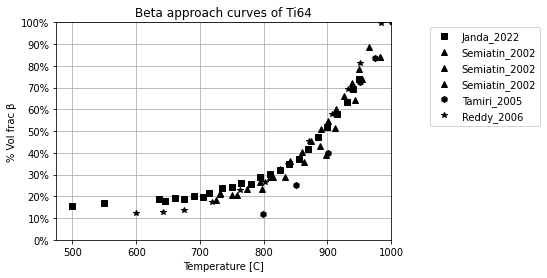

In [5]:
beta_approach_curve_plotter(filtered_data)


In [6]:
def testfunc(T, a, b, c, d):
    """Model exponential function for beta approach curves"""
    return a + (b)**(c*(T+d))

Janda_2022
a:15.380492852017476	b:1.0035341331817984	c: 2.7824630778461215	d: -534.787811653264
Semiatin_2002
a:6.77739659875367	b:1.0043494251260492	c: 1.9166301569529465	d: -435.54296888638805
a:10.969512951783704	b:1.0038577209576867	c: 2.3356773660181562	d: -503.48161781470276
a:16.993812414827495	b:1.0050943817949856	c: 2.244597353907761	d: -610.081056321081
Tamiri_2005
a:-30.195744398601356	b:1.0050043066990884	c: 1.1572881467665996	d: -155.81201181755566
Villa_2019
Reddy_2006
a:6.2870677479286226	b:1.003958728724647	c: 2.014072091301915	d: -411.96034463333336


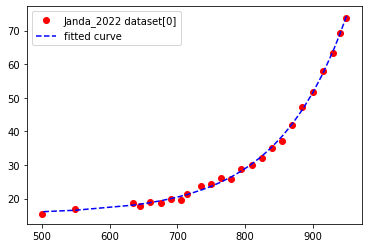

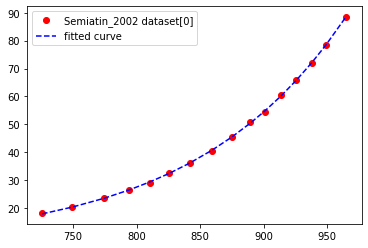

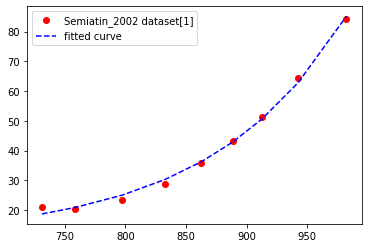

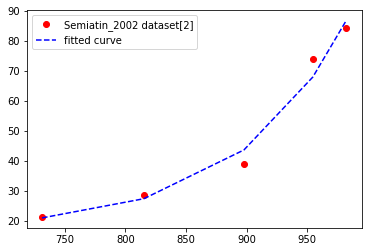

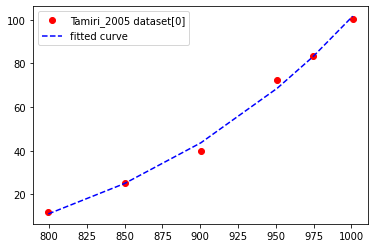

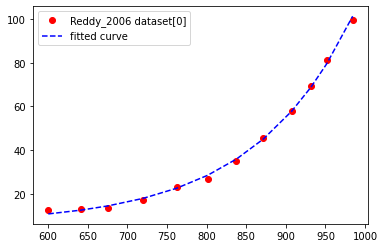

In [7]:

for paper in filtered_data['Papers']:
    print(paper)
    for curve_num, curve in enumerate(filtered_data['Papers'][paper]['Curves']):
        T = curve.iloc[:,0]
        volfracbeta = curve.iloc[:,1]

        param, param_cov = curve_fit(testfunc, T, volfracbeta)
        print(f"a:{param[0]}\tb:{param[1]}\tc: {param[2]}\td: {param[3]}")
        fit_volfracbeta = ( param[0] + param[1]**( param[2]*(T+param[3]) ) )
 
        plt.figure()
        plt.plot(T, volfracbeta, 'o', color ='red', label =f"{paper} dataset[{curve_num}]")
        plt.plot(T, fit_volfracbeta, '--', color ='blue', label ="fitted curve")
        plt.legend()
